In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from sklearn.metrics.pairwise import rbf_kernel
from tqdm import tqdm

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, _compute_ncut
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=5000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified", add_soap=True)
df = qm9.load()
soap_matrix = np.array(df['soap_embedding'].to_list())
umap = UMAP(n_components=32, random_state=42)
reduced_soap = umap.fit_transform(soap_matrix)

2026-04-08 11:02:54.241 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-08 11:02:54.462 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-08 11:02:54.462 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-08 11:02:54.464 | INFO     | src.features:compute_soap:162 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-08 11:03:40.309 | SUCCESS  | src.datasets:add_soap:831 - Added SOAP embeddings.
2026-04-08 11:03:40.310 | INFO     | src.datasets:_add_requested_descriptors:148 - Added descriptor column(s): ['soap_embedding']
2026-04-08 11:03:40.314 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:570 - Dropped QM9 rows with null/empty descriptor vectors: dropped=23, remaining=5477, descriptor_cols=['soap_embedding'].
2026-04-08 1

Evaluating Spectral Clustering: 100%|██████████| 23/23 [00:18<00:00,  1.23it/s]


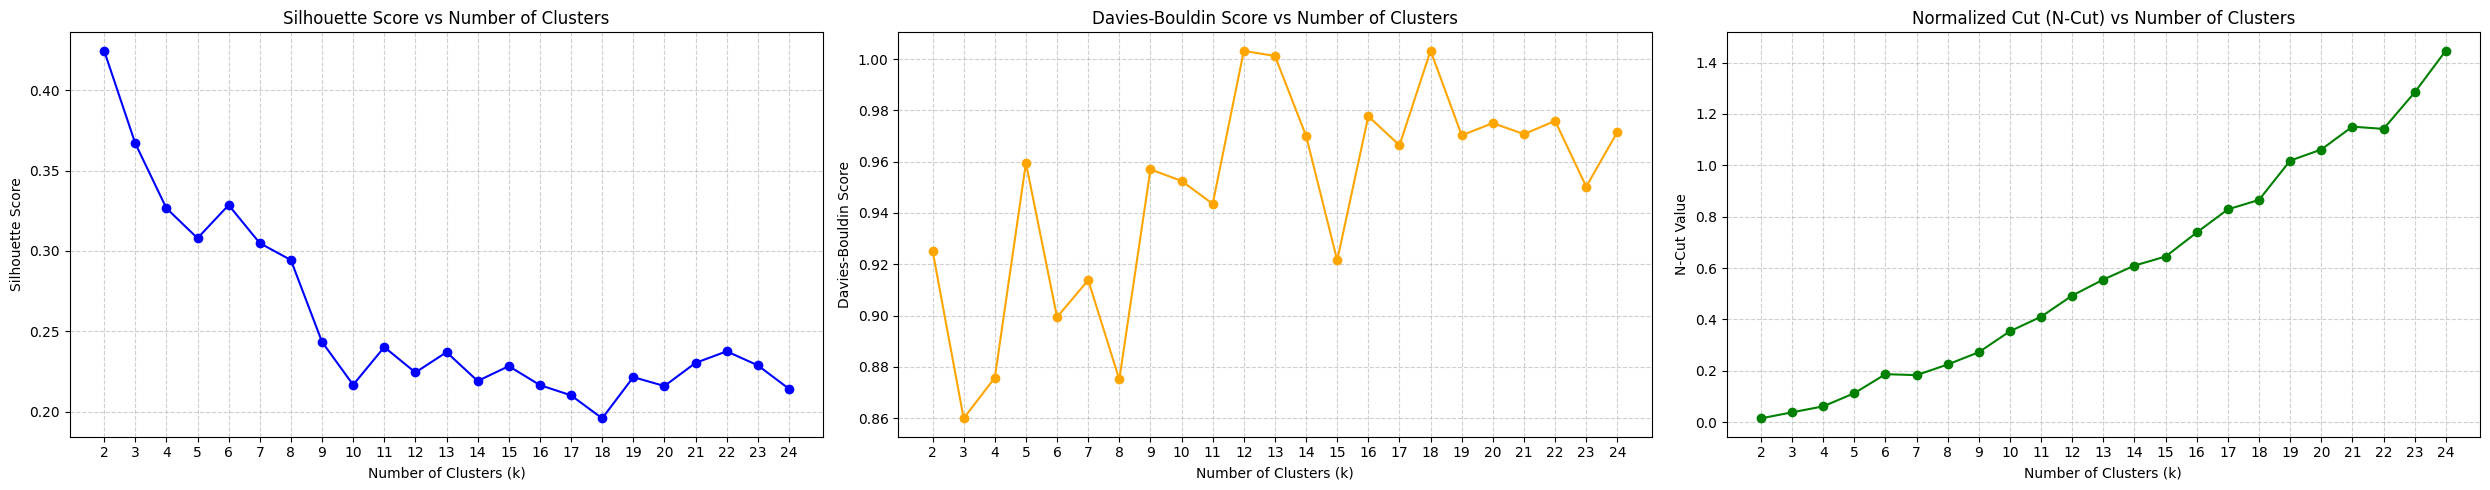

In [4]:

# Helper function to compute the Normalized Cut (N-Cut)
def calculate_ncut(affinity_matrix, labels):
    n_clusters = len(np.unique(labels))
    ncut_val = 0.0
    
    # Calculate the degree of each node (sum of its connection weights)
    degrees = np.sum(affinity_matrix, axis=1)
    
    for k in range(n_clusters):
        # Find indices of points in cluster k vs the rest of the graph
        in_cluster = (labels == k)
        out_of_cluster = ~in_cluster
        
        # Volume of the cluster (sum of degrees of all nodes in this cluster)
        vol_k = np.sum(degrees[in_cluster])
        
        # Prevent division by zero if a cluster is somehow empty or completely isolated
        if vol_k == 0:
            continue
            
        # Cut size: sum of weights on edges connecting cluster k to the rest of the graph
        cut_k = np.sum(affinity_matrix[in_cluster][:, out_of_cluster])
        
        # Add the normalized cut for this cluster
        ncut_val += cut_k / vol_k
        
    return ncut_val

sil_scores = []
db_scores = []
ncut_scores = []

k_max = 25
k_range = range(2, k_max)

for i in tqdm(k_range, desc="Evaluating Spectral Clustering"):
    # 2. Fit Spectral Clustering using the precomputed graph
    # (This is much faster than letting it recalculate the RBF kernel every iteration)
    sc = SpectralClustering(
        n_clusters=i, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42
         # Number of times to run k-means on the eigenvectors
    )
    labels = sc.fit_predict(reduced_soap)
    
    # 3. Calculate Metrics
    sil = silhouette_score(reduced_soap, labels)
    db = davies_bouldin_score(reduced_soap, labels)
    ncut = _compute_ncut(reduced_soap, labels)
    
    sil_scores.append(sil)
    db_scores.append(db)
    ncut_scores.append(ncut)

plt.figure(figsize=(25, 5))

# Plot 1: Silhouette Score (Higher is better)
plt.subplot(1, 3, 1)
plt.plot(k_range, sil_scores, marker='o', color='blue')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Davies-Bouldin Score (Lower is better)
plt.subplot(1, 3, 2)
plt.plot(k_range, db_scores, marker='o', color='orange')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Normalized Cut (Lower is better)
plt.subplot(1, 3, 3)
plt.plot(k_range, ncut_scores, marker='o', color='green')
plt.title('Normalized Cut (N-Cut) vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('N-Cut Value')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# peaks: 9 or 14
k = 8
labels = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42).fit_predict(reduced_soap)
df = df.with_columns(pl.Series("cluster_label", labels))

sil = silhouette_score(reduced_soap, labels)
db = davies_bouldin_score(reduced_soap, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.2944
Davies-Bouldin Score: 0.8751


In [12]:
reducer = 'UMAP'
create_chemiscope_viewer(df, soap_matrix, labels=labels, reduction_method=reducer)

Running UMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_UMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_UMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Number of valid clusters (excluding noise): 8


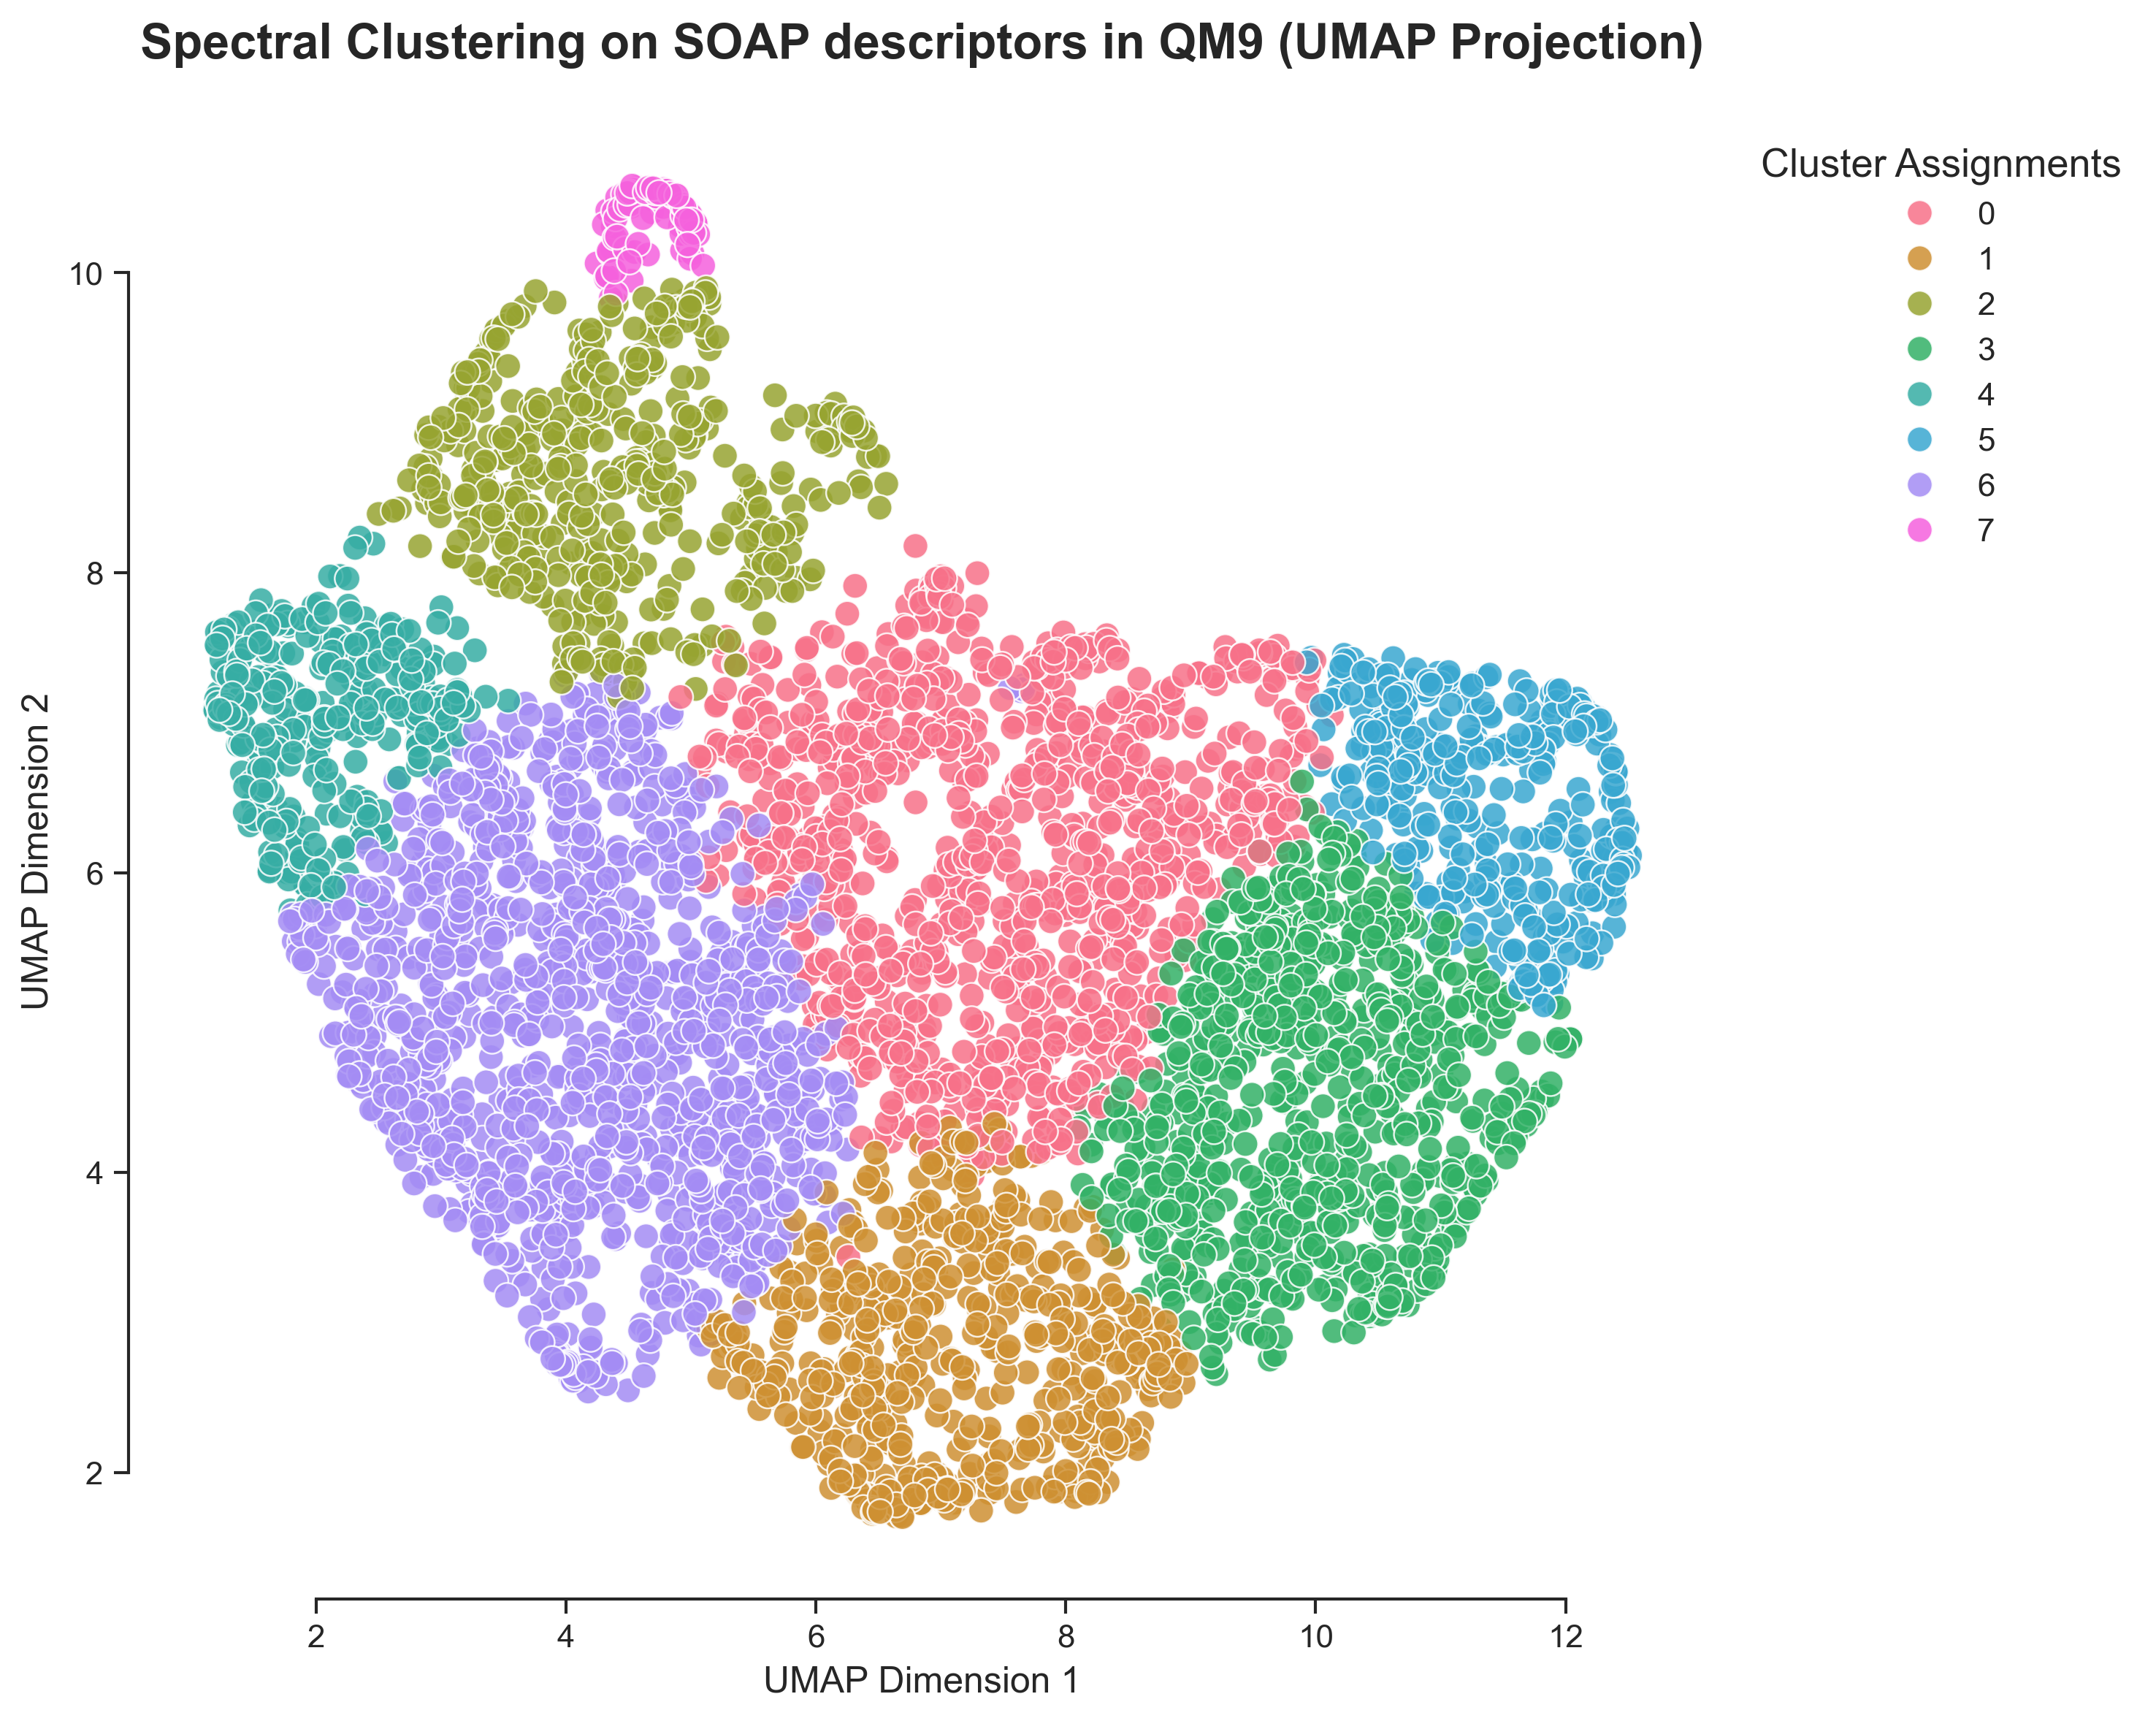

In [16]:
umap = UMAP(n_components=2,random_state=42)
umap_embedding = umap.fit_transform(soap_matrix)

# pca reducer
#pca_reducer = PCA(n_components=2, random_state=42)
#pca_embedding = pca_reducer.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        umap_embedding[noise_mask, 0], 
        umap_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
print(f"Number of valid clusters (excluding noise): {n_clusters}")
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=umap_embedding[cluster_mask, 0], 
        y=umap_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Spectral Clustering on SOAP descriptors in QM9 (UMAP Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/clustering/spectral/soap_reduced/spectral_soap_umap_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [18]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns along with the count of elements.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.len().alias("count"),  # Adds the number of elements per cluster
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

print("SpectralClustering")
cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


SpectralClustering
shape: (8, 55)
┌───────────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ 

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_69907/1544512762.py:10: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
